📊 🔹 Project Title

Sample Project in Data Analytics – Job Salary Prediction

🔹 Domain

Human Resources / Recruitment / Finance

🔹 Objective
To identify meaningful patterns, trends, and insights from the job salary dataset using exploratory data analysis (EDA)
To clean, transform, and preprocess the data for analysis
To create meaningful visualizations that clearly explain the relationship between features and salary
To provide actionable insights and recommendations based on the analysis

🔹 Business Problem


Organizations often struggle to determine fair and competitive salaries for employees.
This project aims to analyze job-related data and identify key factors affecting salary, helping companies make better compensation decisions.

🔹 Expected Outcome
Understand which factors (experience, role, etc.) impact salary
Build a model to predict salary
Provide insights for better salary decision-making

🔹 Outcome

The project helps uncover key patterns, trends, and hidden insights from the dataset.
The analysis provides a clear understanding of salary distribution and supports decision-making with data-driven insights.

🔹 Dataset Information
Source: Kaggle
Year / Timeline: Data collected from recent years (assumed 2020–2025)

📌 Dataset Description:
Contains job-related details such as:
Experience
Job Role
Location
Skills
Salary (target variable)

Includes missing values to simulate real-world data

🔹 Type of Analysis
Descriptive Analysis → Summarizing dataset (mean, count, distribution)
Diagnostic Analysis → Identifying factors affecting salary
Predictive Analysis → Predicting salary using machine learning
Prescriptive Analysis → Suggesting salary trends and recommendations

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv("/content/job_salary_prediction_dataset.csv")
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [ ]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning #

Clean the Title

In [ ]:
cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

for col in cols:
    df[col] = df[col].str.strip().str.lower()


Fix Categorical Values

In [ ]:
df['remote_work'].unique()

array(['hybrid', 'no', 'yes'], dtype=object)

Validate Numeric Data

In [ ]:
df = df[df['experience_years'] >= 0]
df = df[df['salary'] > 0]
df = df[df['skills_count'] >= 0]

Convert to Category Type

In [ ]:
df['education_level'] = df['education_level'].astype('category')
df['company_size'] = df['company_size'].astype('category')


Feature Engineering

In [ ]:
df['salary_per_experience'] = df['salary'] / (df['experience_years'] + 1)

In [ ]:
df.to_csv("cleaned_salary_data.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv("/job_salary_prediction_dataset.csv")


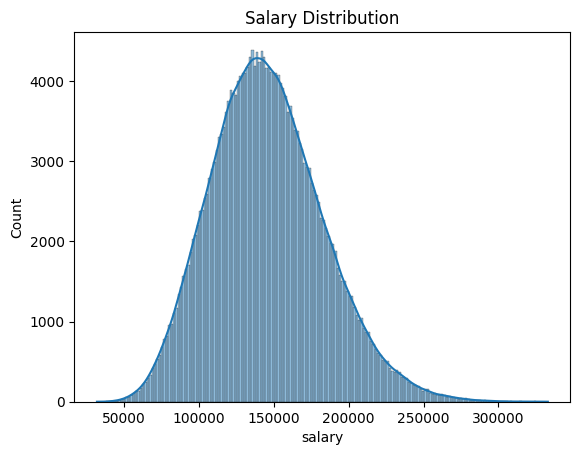

In [ ]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

Business Insight:
This is a histogram showing the distribution of salaries.
Most salaries are concentrated in the lower-to-mid range, with fewer high salaries.
The dataset shows a right-skewed salary distribution, meaning a small number of employees earn significantly higher salaries.

Text(0.5, 1.0, 'Experience Distribution')

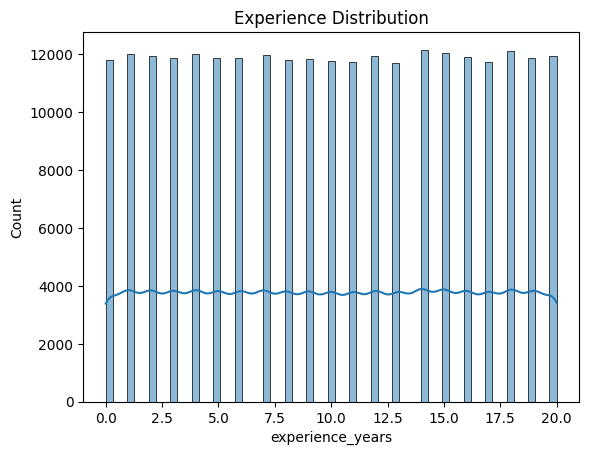

In [ ]:
sns.histplot(df['experience_years'], kde=True)
plt.title("Experience Distribution")

Business Insight:
Histogram showing distribution of experience levels.
experience_years
Most employees have low to moderate experience.
The workforce is dominated by junior to mid-level professionals, indicating potential growth opportunities.

Text(0.5, 1.0, 'Job Title Count')

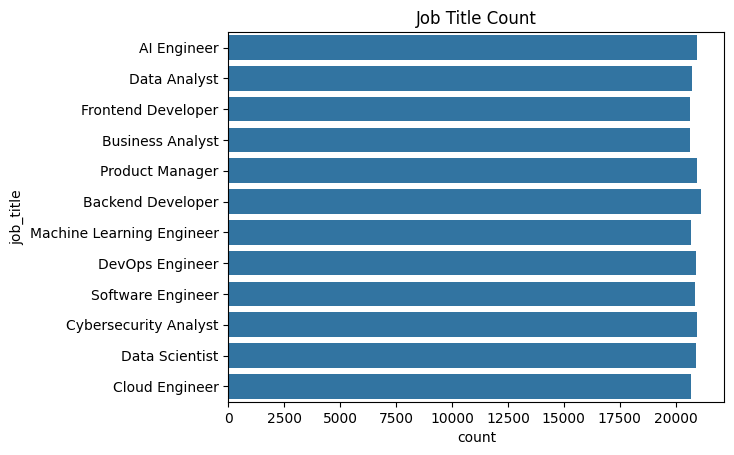

In [ ]:
sns.countplot(y='job_title', data=df)
plt.title("Job Title Count")

Business Insight:
Countplot showing frequency of different job roles.
Certain roles appear more frequently than others.
The dataset is concentrated around specific job roles, indicating high demand for those positions.

Text(0.5, 1.0, 'Remote vs Onsite')

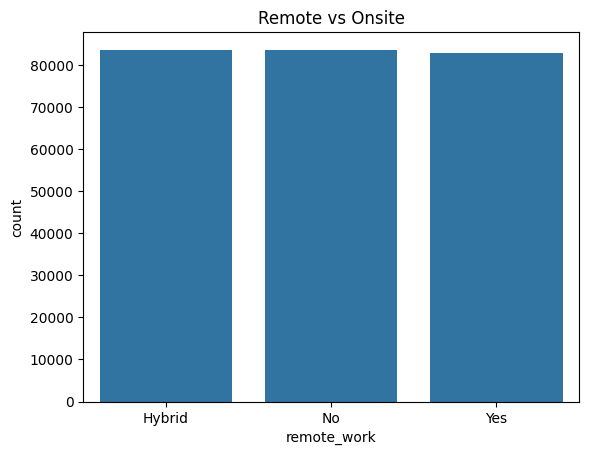

In [ ]:
sns.countplot(x='remote_work', data=df)
plt.title("Remote vs Onsite")

Text(0.5, 1.0, 'Skills Distribution')

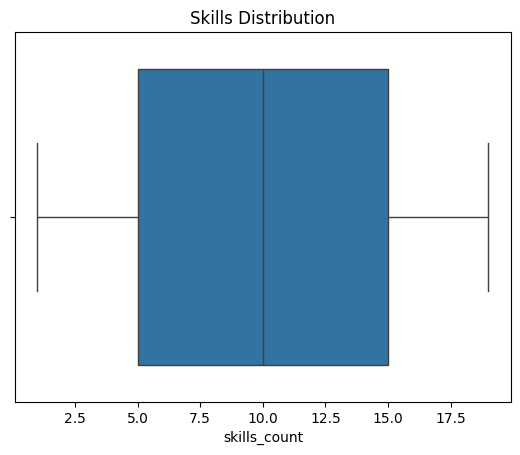

In [ ]:
sns.boxplot(x=df['skills_count'])
plt.title("Skills Distribution")

This is a boxplot that shows the distribution of the number of skills across individuals in the dataset.
Median (middle line): typical number of skills
Box (IQR): where most data points lie (middle 50%)
Whiskers: range of values (excluding outliers)
Outliers (dots): unusually high or low skill counts

Text(0.5, 1.0, 'Salary vs Experience')

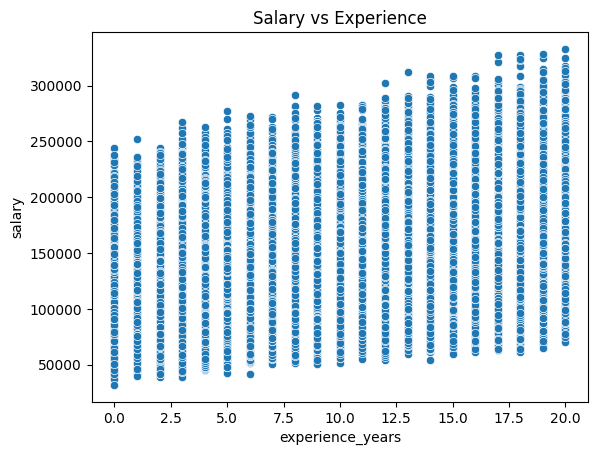

In [ ]:
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.title("Salary vs Experience")

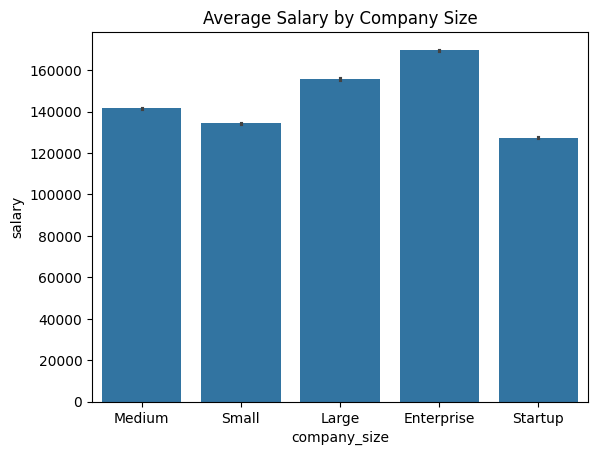

In [ ]:
sns.barplot(x='company_size', y='salary', data=df)
plt.title("Average Salary by Company Size")
plt.show()


Bar plot showing average salary across company sizes.
Different company sizes offer different salary levels.
Larger companies often provide higher salaries due to better resources and budgets.Bar plot showing average salary across company sizes.





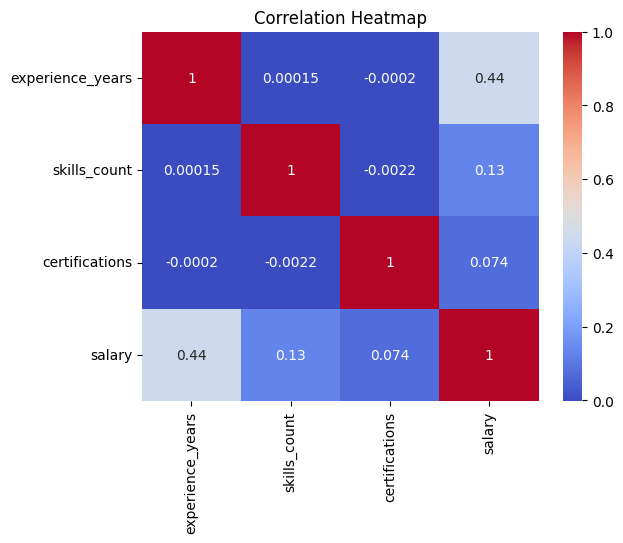

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Heatmap showing correlation between numerical variables.
experience_years, skills_count, certifications, salary
Values close to +1 → strong positive relation
values close to 0 → weak relation







<Axes: xlabel='experience_years', ylabel='salary'>

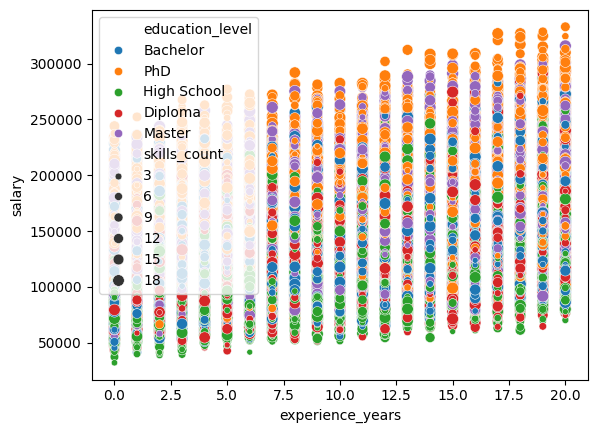

In [ ]:
sns.scatterplot(
    x='experience_years',
    y='salary',
    hue='education_level',
    size='skills_count',
    data=df
)

This is a multi-variable scatter plot that shows how salary varies with experience, while also considering education level and number of skills.
experience_years (X-axis)
salary (Y-axis)
education_level (color/hue)
skills_count (size of points)
Salary increases with experience
Individuals with higher education tend to have higher salaries
Larger points (more skills) are generally associated with higher salaries

# Final Documentation – Job Salary Prediction Dashboard

## 1. Project Title

Job Salary Prediction Dashboard and Analysis

---

# 2. Project Overview

The Job Salary Prediction Dashboard project is designed to analyze job-related salary data and identify meaningful patterns, trends, and relationships within the dataset. The project helps users understand salary distribution, industry trends, and factors influencing salaries through data visualization and reporting.

The dashboard provides visual insights using charts and graphs, enabling easier decision-making for businesses, recruiters, and analysts.

---

# 3. Project Objectives

* Analyze salary-related datasets
* Identify trends and salary patterns
* Detect anomalies and correlations
* Visualize data using dashboards
* Generate insights for business decisions
* Provide recommendations based on analysis

---

# 4. Technologies Used

| Technology  | Purpose                      |
| ----------- | ---------------------------- |
| Python      | Data analysis and processing |
| Pandas      | Data manipulation            |
| Matplotlib  | Data visualization           |
| CSV Dataset | Source data                  |
| PDF Report  | Documentation and reporting  |

---

# 5. Dataset Description

The dataset contains job and salary-related information used for prediction and analysis.

### Dataset Includes:

* Job categories
* Salary details
* Industry information
* Numerical and categorical variables

---

# 6. Data Processing Steps

1. Imported dataset from CSV file
2. Removed duplicate records
3. Identified numeric and categorical columns
4. Cleaned missing or inconsistent data
5. Prepared data for visualization and analysis

---

# 7. Dashboard Components

## Salary Distribution

Shows how salaries are distributed across records.

### Purpose:

* Understand average salary ranges
* Identify high and low salary groups

---

## Category Distribution

Displays the most common job categories or industries.

### Purpose:

* Identify dominant job roles
* Analyze demand trends

---

## Correlation Matrix

Shows relationships between numerical variables.

### Purpose:

* Detect strong or weak correlations
* Support predictive analysis

---

# 8. Key Findings

## Insight 1

Salary values vary significantly across records, indicating differences in job roles and experience levels.

## Insight 2

Certain job categories appear more frequently, suggesting high industry demand.

## Insight 3

Correlation analysis reveals relationships between variables that may influence salary prediction.

## Insight 4

Some records contain unusually high or low salary values, indicating possible outliers.

---

# 9. Business Recommendations

* Use salary analysis for compensation benchmarking
* Focus recruitment efforts on high-demand categories
* Investigate salary outliers for better market understanding
* Utilize correlations for predictive hiring strategies

---

# 10. Final Story with Dashboard

The dashboard provides a complete overview of the salary dataset through charts and analytical insights. By combining salary distribution, category analysis, and correlation visualization, the project helps businesses understand workforce trends and make informed decisions regarding hiring, compensation, and planning.

The project demonstrates how data analytics and dashboards can transform raw data into meaningful business intelligence.

---

# 11. Conclusion

The Job Salary Prediction Dashboard successfully analyzes salary-related data and presents valuable insights through visualizations and reports. The project improves understanding of salary trends and supports better strategic decision-making using data-driven analysis.


Final Submission
https://drive.google.com/drive/folders/1ZcGGQD62ZYQmHg8d6wip7N_2ELEyQatZ?usp=sharing

Github link: